# Aggregate population to grid

Aggregate the clipped HRSL raster to the 1 km analysis grid, compute population per grid cell, and save the grid with population attributes for downstream accessibility and burden analysis.

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.features import geometry_mask

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config import (
    CITY_NAME,
    CRS_WGS84,
    FILES,
    ensure_project_dirs,
    savefig,
    print_config_summary,
)

ensure_project_dirs()
print_config_summary()

===== CONFIG =====
City: Delhi
BBOX: {'lon_min': 76.8, 'lat_min': 28.4, 'lon_max': 77.4, 'lat_max': 28.95}
Grid Size: 1000 m
Top-K Hospitals: 3
Alpha: 1.5
Beta: 1.0
HRSL Path: /Users/suvo/Projects/urban-healthcare/data/raw/population/population_20_lon_70_general-v1.5.tif


In [2]:
grid = gpd.read_parquet(FILES["grid"])
grid.head()

,grid_id,geometry,cell_area_m2,cell_area_km2
0,g_00000,"POLYGON ((8550336.893 3300498.882, 8550336.893...",1000000.0,1.0
1,g_00001,"POLYGON ((8550336.893 3301498.882, 8550336.893...",1000000.0,1.0
2,g_00002,"POLYGON ((8550336.893 3302498.882, 8550336.893...",1000000.0,1.0
3,g_00003,"POLYGON ((8550336.893 3303498.882, 8550336.893...",1000000.0,1.0
4,g_00004,"POLYGON ((8550336.893 3304498.882, 8550336.893...",1000000.0,1.0


In [3]:
with rasterio.open(FILES["hrsl_clipped"]) as src:
    hrsl_data = src.read(1)
    hrsl_transform = src.transform
    hrsl_crs = src.crs
    hrsl_nodata = src.nodata
    hrsl_bounds = src.bounds

print("HRSL CRS:", hrsl_crs)
print("HRSL bounds:", hrsl_bounds)
print("HRSL nodata:", hrsl_nodata)
print("HRSL shape:", hrsl_data.shape)

HRSL CRS: EPSG:4326
HRSL bounds: BoundingBox(left=76.79986111111657, bottom=28.39986111110983, right=77.40013888889483, top=28.950138888888045)
HRSL nodata: nan
HRSL shape: (1981, 2161)


In [4]:
grid_hrsl = grid.to_crs(hrsl_crs)
print("Grid CRS:", grid_hrsl.crs)

Grid CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]


In [5]:
if hrsl_nodata is not None:
    hrsl_data = np.where(hrsl_data == hrsl_nodata, 0, hrsl_data)

hrsl_data = np.where(np.isnan(hrsl_data), 0, hrsl_data)

In [6]:
population_values = []

for geom in grid_hrsl.geometry:
    mask_array = geometry_mask(
        [geom],
        transform=hrsl_transform,
        invert=True,
        out_shape=hrsl_data.shape
    )
    pop_value = hrsl_data[mask_array].sum()
    population_values.append(float(pop_value))

grid["population"] = population_values

In [7]:
grid["population_density_km2"] = grid["population"] / grid["cell_area_km2"]

print("Total population in clipped grid:", grid["population"].sum())
print("Nonzero cells:", (grid["population"] > 0).sum())
grid[["grid_id", "population", "population_density_km2"]].head()

Total population in clipped grid: 26339196.343943
Nonzero cells: 4419


,grid_id,population,population_density_km2
0,g_00000,228.076035,228.076035
1,g_00001,428.506490,428.506490
2,g_00002,290.278590,290.278590
3,g_00003,380.126725,380.126725
4,g_00004,283.367195,283.367195


Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/03_grid_population.png


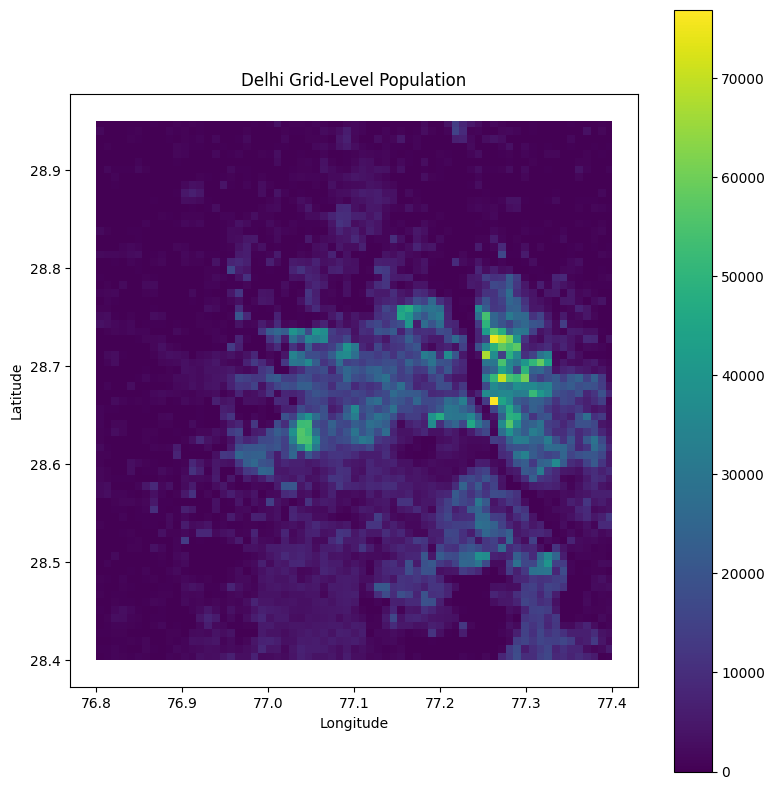

In [8]:
fig, ax = plt.subplots(figsize=(8, 8))
grid_wgs84 = grid.to_crs(CRS_WGS84)

grid_wgs84.plot(
    column="population",
    ax=ax,
    legend=True,
    cmap="viridis",
    linewidth=0
)

ax.set_title(f"{CITY_NAME} Grid-Level Population")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "03_grid_population.png")
plt.show()

Saved: /Users/suvo/Projects/urban-healthcare/outputs/figures/03_population_density_km2.png


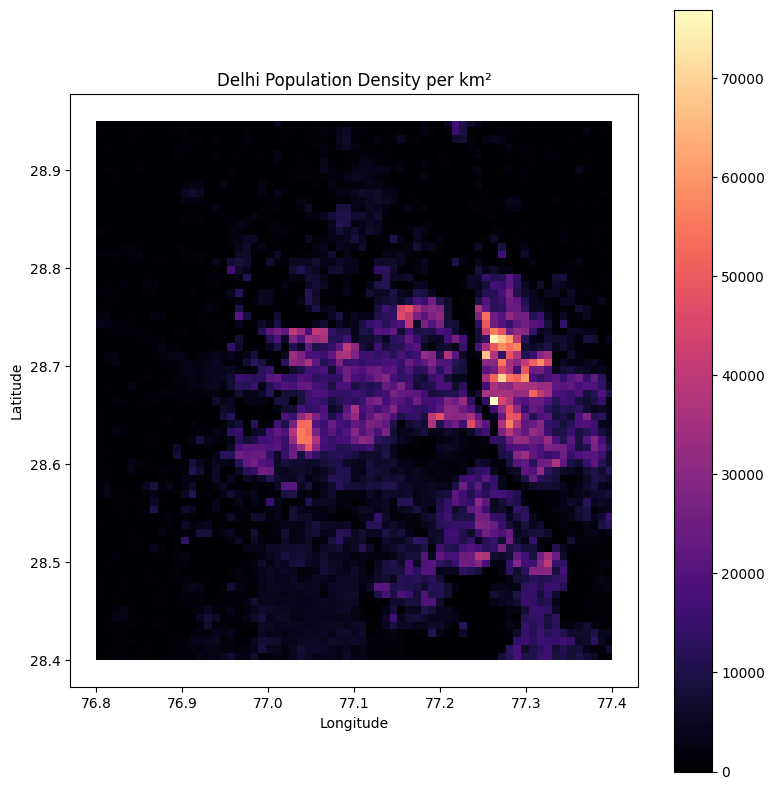

In [9]:
fig, ax = plt.subplots(figsize=(8, 8))
grid_wgs84.plot(
    column="population_density_km2",
    ax=ax,
    legend=True,
    cmap="magma",
    linewidth=0
)

ax.set_title(f"{CITY_NAME} Population Density per km²")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()

savefig(fig, "03_population_density_km2.png")
plt.show()

In [10]:
grid.to_parquet(FILES["grid_population"], index=False)
print("Saved grid population to:", FILES["grid_population"])

Saved grid population to: /Users/suvo/Projects/urban-healthcare/data/processed/grid_population.parquet
